# Twisted bilayer h-BN STEM multislice comparison

This notebook runs **STEM multislice simulations** (via `pyms`) for two bilayer h-BN structures and compares the resulting HAADF images side-by-side.

In this repository we use two `.p1` structure files (exported from VESTA) that correspond to two relative stackings/registries of a twisted bilayer. We label the outputs as *AA* and *AA′* for convenience (matching the manuscript discussion).

Outputs written by this notebook:
- `twisted comparison.png` / `twisted comparison.svg` (raw simulated HAADF images)
- `twisted comparison blurred.png` / `twisted comparison blurred.svg` (Gaussian-blurred versions to emphasize larger-scale contrast variations)

In [1]:
import pyms
import numpy as np
import matplotlib.pyplot as plt
import torch
#%matplotlib widget
%matplotlib inline

## Load structures (.p1)

We load two bilayer structures from `.p1` files. These were generated externally (VESTA) and are read into `pyms.structure` objects using fractional coordinates.

In [2]:
# This looks for the local file "h-BN.p1". The p1 file type was produced by Vesta and is compatible with the pyms package.
fname = "figures/figure2/inputs/hbn_bilayer_8deg_v2.p1"
fname2 = "figures/figure2/inputs/hbn_bilayer_188deg_v2.p1"

structure = pyms.structure.fromfile(fname,temperature_factor_units='urms',atomic_coordinates='fractional')
structure2 = pyms.structure.fromfile(fname2,temperature_factor_units='urms',atomic_coordinates='fractional')

## Inspect the projected potential (sanity check)

Generate a projected potential for `structure` on a grid and display it. This is a quick visual check that the structure loaded correctly and that the sampling/grid size is reasonable.

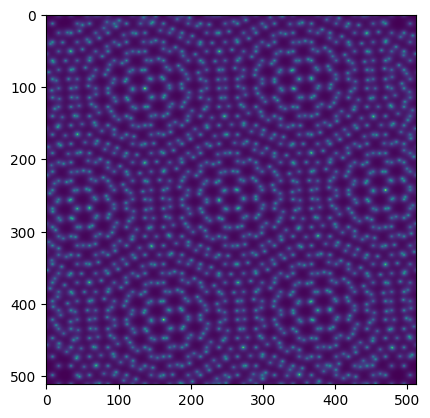

In [3]:
#Create a quickplot of our structure, you can play with scaling using the atomscale parameter
tiling = [1,1]
#fig = structure.quickplot(atomscale=2,block=False,tiling=tiling)

pixels = [512,512]

potential = structure.make_potential(pixels,tiling=tiling,displacements=True)

fig,ax = plt.subplots()
ax.imshow(potential[0].cpu())
plt.show()


## Choose multislice slicing planes

`pyms` represents the specimen as a stack of slices along *z*. Here we choose slice boundaries (in fractional coordinates along the unit cell `c` axis) and visualize them for each structure.

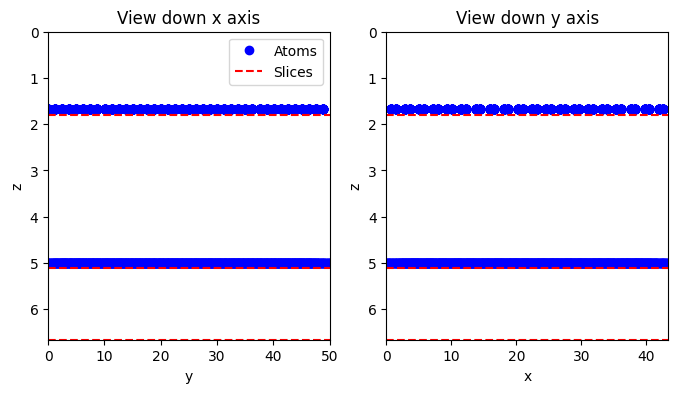

In [4]:
plt.close()
# Select slices under the planes of the atoms
slices = np.asarray([1.8,5.1,structure.unitcell[2]]) /structure.unitcell[2]

# Generate a slicing figure to visualize what has been done
plot = structure.generate_slicing_figure(slices,show=True)

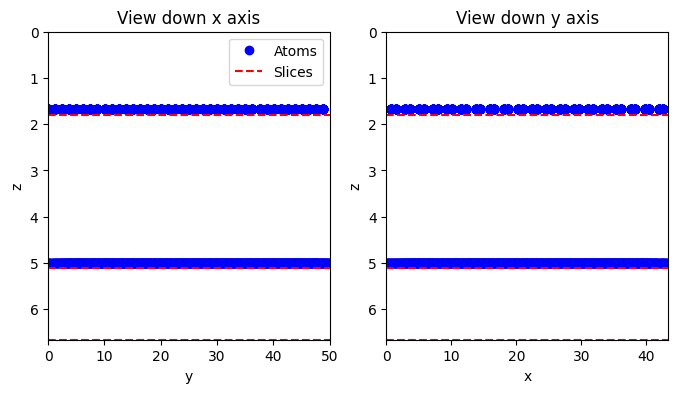

In [5]:
plt.close()
# Select slices under the planes of the atoms
slices = np.asarray([1.8,5.1,structure2.unitcell[2]]) /structure2.unitcell[2]

# Generate a slicing figure to visualize what has been done
plot = structure2.generate_slicing_figure(slices,show=True)

## Run STEM multislice (HAADF)

We simulate HAADF-STEM images for each structure using the same microscope parameters. Key settings used below:
- Accelerating voltage: **100 keV**
- Convergence semi-angle (aperture): **30 mrad**
- HAADF detector: **80–150 mrad**
- Frozen phonons: **nfph = 40**
- ROI: chosen so the sampled field of view is square in real space
- gridshape: simulation grid size

The result dictionaries (`result`, `result2`) contain the simulated STEM images.

In [8]:
# Use gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Accelerating voltage in eV
eV = 100*(1000)

# Aperature
app = 30

# Material thickness in Angrstroms
thicknesses = [[7]]

# Detector
# This can be a list of lists specifying the min and max values for the detector dimensions in mrad
#                           BF          MAADF         HAADF
# Example: detectors = [[min, max], [min2, max2], [min3, max3]]
# We are only interested in HAADF here
detectors = [[80,150]]

# Defocus -- We want a defocus series so we can see what effect focus has
# This is in Angstroms
df = 0 #np.linspace(-40, 40, 11)

# Number of frozen phonon modes
nfph = 40

# Choose a square real-space ROI from the rectangular unit cell.
# generate_STEM_raster expects ROI = [y0, x0, y1, x1].
rsize_y, rsize_x = structure.unitcell[:2]
square_side = min(rsize_y, rsize_x)
roi = [
    0.5 * (1 - square_side / rsize_y),
    0.0,
    0.5 * (1 + square_side / rsize_y),
    1.0,
]

pixels = [1024,1024]

# calculate
result = pyms.STEM_multislice(
    structure,
    eV,
    app,
    thicknesses,
    nfph=nfph,
    detector_ranges=detectors,
    showProgress=False,
    tiling=tiling,
    gridshape=pixels,
    subslices=[1.0],
    df=df,
    ROI=roi,
    device_type=device)

# calculate
result2 = pyms.STEM_multislice(
    structure2,
    eV,
    app,
    thicknesses,
    nfph=nfph,
    detector_ranges=detectors,
    showProgress=False,
    tiling=tiling,
    gridshape=pixels,
    subslices=[1.0],
    df=df,
    ROI=roi,
    device_type=device)


## Compare simulated images

We Fourier-interpolate the simulated images to a convenient display size, then plot the two HAADF images side-by-side and save the figure.

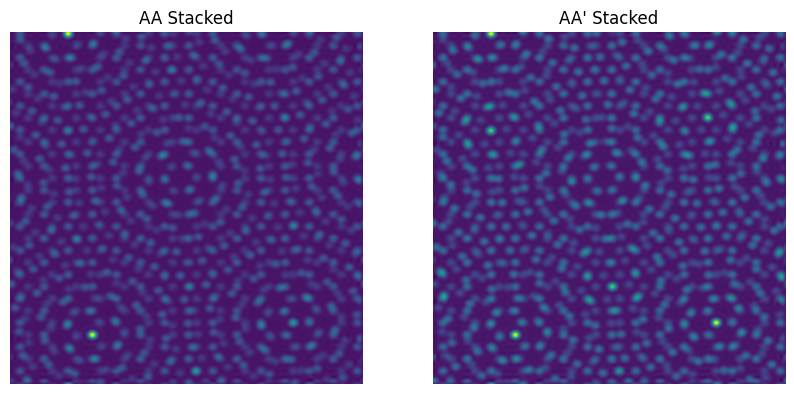

In [10]:
def interp_image(im, tiling, interp_shape=[512,512]):
    return pyms.utils.fourier_interpolate(np.tile(im, tiling), interp_shape)

im = interp_image(result['STEM images'], tiling=tiling)
im2 = interp_image(result2['STEM images'], tiling=tiling)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,10))

ax[0].imshow(im)
ax[0].set_title('AA Stacked')
ax[0].set_axis_off()
ax[1].imshow(im2)
ax[1].set_title('AA\' Stacked')
ax[1].set_axis_off()
plt.savefig('figures/figure2/outputs/twisted comparison.png', bbox_inches='tight', dpi=300)
plt.savefig('figures/figure2/outputs/twisted comparison.svg', bbox_inches='tight')
plt.show()

## Blurred comparison (blurred to qualitatively match experiment)

Apply a Gaussian blur to the simulated images to suppress atomic-scale contrast and highlight larger-scale variations. The blurred comparison is saved as a separate figure.

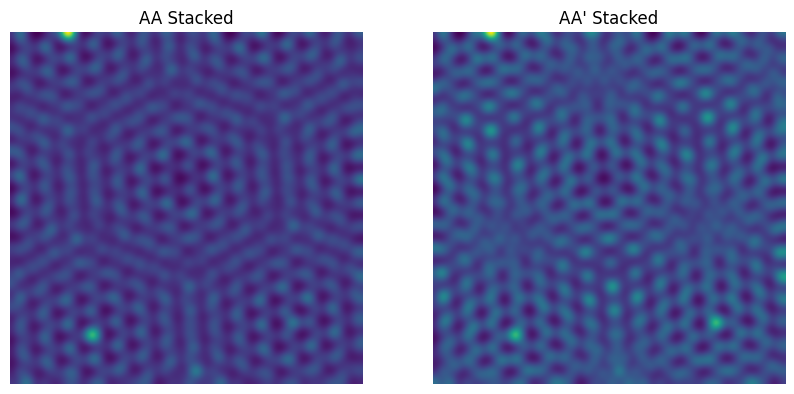

In [11]:
from scipy.ndimage import gaussian_filter

# strength of blur (must be positive)
sigma = 8
blurred_image = gaussian_filter(im, sigma=sigma, mode='reflect')
blurred_image2 = gaussian_filter(im2, sigma=sigma, mode='reflect')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,10))

ax[0].imshow(blurred_image)
ax[0].set_title('AA Stacked')
ax[0].set_axis_off()
ax[1].imshow(blurred_image2)
ax[1].set_title('AA\' Stacked')
ax[1].set_axis_off()
plt.savefig('figures/figure2/outputs/twisted comparison blurred.png', bbox_inches='tight', dpi=300)
plt.savefig('figures/figure2/outputs/twisted comparison blurred.svg', bbox_inches='tight')
plt.show()